# Analyzing the Market Impact of RBI Forward Guidance

**Author:** Darshil Trivedi

---

## Project Overview

The goal of this project was to determine if it was possible to predict the impact of RBI's Monetary Policy Committee's(MPC) resolutions and the governor's statements on the various sectoral indices of the Indian Stock Exchange.

Instead of just looking at the official repo-rate changes(which are usually already priced-in by the time the statements are released), I wanted to analyse the *sentiment* of the statements, the forward-guidance, in the statements and see if they drive the stock prices.

---

## Methodology

**1. Data Collection and Text Extraction**

The RBI's website uses legacy ASP.NET technology with hidden JavaScript paginations making it extremely difficult to scrape traditionally. I built a headless Selenium scraper to bypass this and download 10 years of policy PDFs (from the day of the first meeting of the MPC).

I collected the market data(opening and closing values) of 8 different sectoral indices, which I wanted to study, along with the Nifty 50 itself, using the yfinance library

**2. Sentiment Analysis**

I extracted the text from the given PDFs, cleaned it, and separated each sentence into a different chunk. I got the exact sentiment rating for each chunk by passing it to the zero-shot classification model `facebook/bart-large-mnli` to score how hawkish/dovish/neutral the statement was. After this I discarded chunks which had a high *Shannon's Entropy*, i.e, chunks which were either ambiguous, or about which the model was unsure of and then finally to get the sentiment score for the entire document as a whole I took a *Neutral-penalised Inverse-Entropy weighed mean* of every chunk in the document (i.e. I assigned higher weights to chunks about whom a. the model was sure of(less entropy) and b. Actually contained a hawkish/dovish statement and wasn't neutral and vice-versa)

**3. Calculating the abnormal rate of return**

To ensure that the changes/impacts I was measuring were strictly because of the forward-guidance of the policy documents and not external factors like war/plague/foreign markets/elections etc. I had to calculate the *abnormal rate of return* (ARR) on the date of the release of the policy document. To do this, I implemented an "event-study design to isolate the market data from external factors and used the market model, as defined by  William Sharpe(1963)which defines the return of a security as a linear function of the market's return.(For the purpose of this study I used the Nifty_50 as the benchmark/'market' and the sectoral indices as the 'security')

The linear function stated by him was :
`Actual Return = Alpha + (Beta * Market Return) + ARR`

For intraday trading the value of Alpha is considered to be practically 0 so we can safely disregard it and to calculate the Beta(the sensitivity of the security to the market) I used a 120-day rolling window to calculate `Covariance(Sector, Market) / Variance(Market)`

**4. Statistical Testing and False Discovery Rate**

I ran OLS regressions between my sentiment rating and the `ARR` of the 8 sectoral indices to see if and how the policy documents impacted the market.

However, since I was testing 8 different sectoral indices respectively, I ran-into the "Multiple Comparisons Problem", which basically means that, statistically, if you test enough things, something would look significant by pure luck alone, which is why I had to apply the **Benjamini-Hochberg (FDR) correction** to adjust my p-values to prevent false positives.

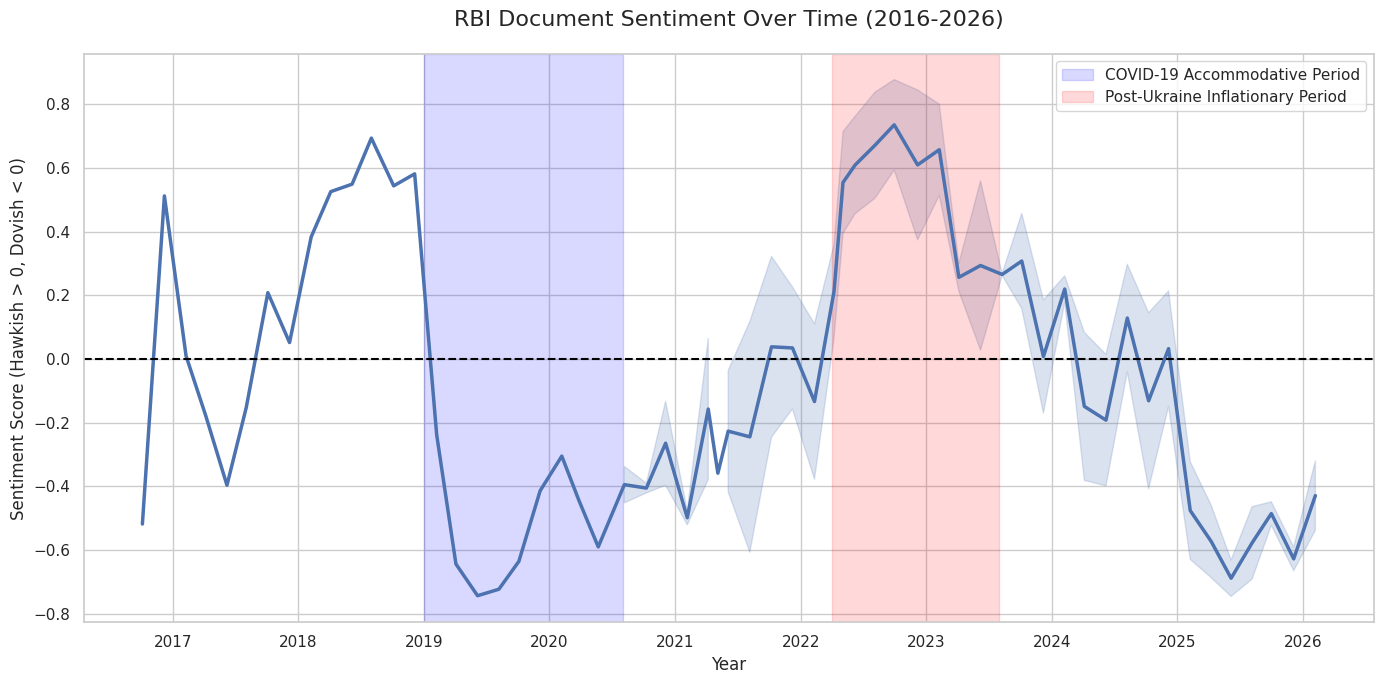

In [40]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open('../data/final_sentiment_score_1.json', 'r') as f:
    sentiments = json.load(f)

df_sentiment = pd.DataFrame(list(sentiments.items()), columns=['filename', 'raw_score'])
dates = []
for fname in df_sentiment['filename']:
    date_str = fname[-14:-4]
    dates.append(pd.to_datetime(date_str, format='%d-%m-%Y'))
df_sentiment['date'] = dates
df_sentiment = df_sentiment.sort_values('date').reset_index(drop=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

ax = sns.lineplot(x='date', y='raw_score', data=df_sentiment, linewidth=2.5)
plt.title('RBI Document Sentiment Over Time (2016-2026)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sentiment Score (Hawkish > 0, Dovish < 0)', fontsize=12)

plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

plt.axvspan('2019-01-01', '2020-08-01', color='blue', alpha=0.15, label='COVID-19 Accommodative Period')
plt.axvspan('2022-04-01', '2023-08-01', color='red', alpha=0.15, label='Post-Ukraine Inflationary Period')

plt.legend()
plt.tight_layout()
plt.show()

As we can see by a cursory overview, that the sentiment scores reflect the RBI's known policy shifts. We can notice both a dramtic plunge during the highly dovish phase present both before and at the COVID-19 crisis and a steep rise during the Post-Ukraine hawkish period.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_results = pd.read_csv('../data/regression_results.csv').drop(columns=['Is_Significant'], errors='ignore')
df_results = df_results.sort_values(by='Beta_Sensitivity', ascending=True).reset_index(drop=True)
display(df_results)

,Ticker,Beta_Sensitivity,P-Value_Raw,P-Value_Corrected
0,^CNXPHARMA,-0.537929,0.024690,0.109169
1,^CNXREALTY,-0.396048,0.124825,0.332867
2,^CNXAUTO,-0.096915,0.612152,0.727774
3,^NSEBANK,-0.079225,0.511435,0.727774
4,^CNXIT,-0.051806,0.786065,0.786065
5,^CNXFMCG,0.081279,0.636802,0.727774
6,^CNXPSUBANK,0.215672,0.368051,0.727774
7,^CNXENERGY,0.417183,0.027292,0.109169


In the above cell the Beta_Sensitivty refers to the correlation between the movement of the stock price and the sentiment of the policy document. A negative Beta_Sensitivity implies that the stock is positively impacted by dovish-forward guidance/sentiment and a positive Beta_Sensitivity implies that the stock is positively impacted by hawkish-forward guidance/sentiment.


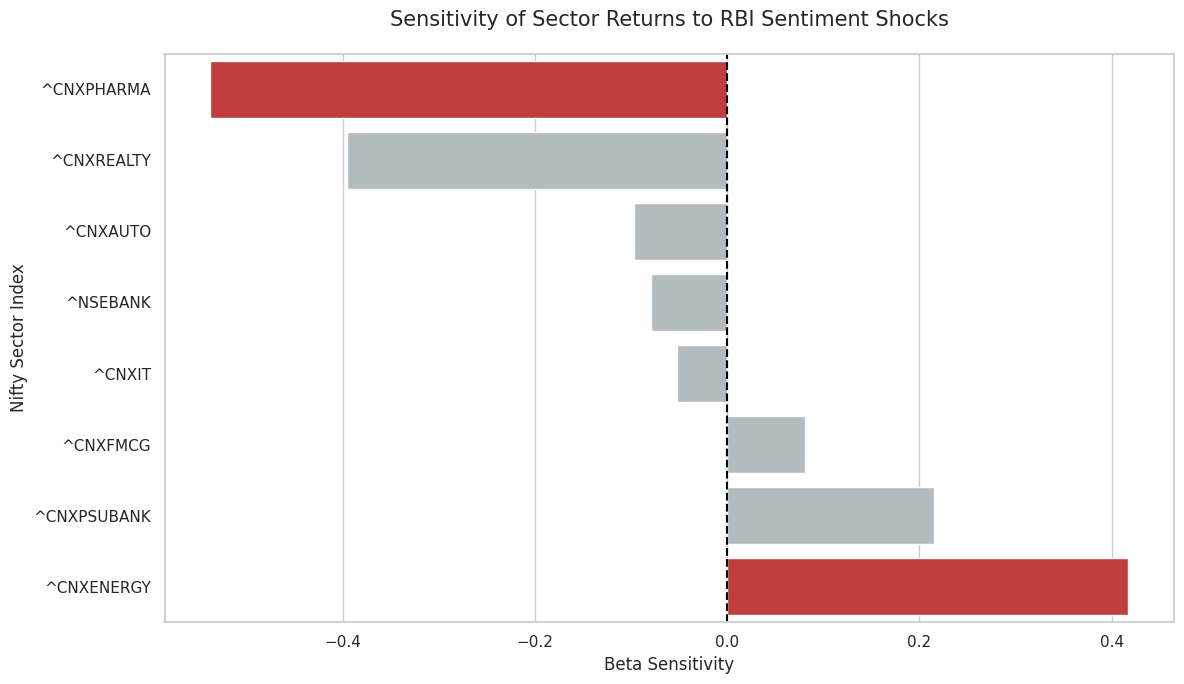

In [33]:
plt.figure(figsize=(12, 7))
colors_list = ['#d62728' if p < 0.05 else '#b0bcc2' for p in df_results['P-Value_Raw']]
color_map = dict(zip(df_results['Ticker'], colors_list))

ax = sns.barplot(x='Beta_Sensitivity', y='Ticker', data=df_results, hue='Ticker',palette=color_map, legend = False)
plt.title('Sensitivity of Sector Returns to RBI Sentiment Shocks', fontsize=15, pad=20)
plt.xlabel('Beta Sensitivity', fontsize=12)
plt.ylabel('Nifty Sector Index', fontsize=12)
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()

# Conclusion and Future Work


This project set out to determine if the forward guidance sentiment within RBI policy documents could predict the intraday market movements of key Nifty sectoral indices. The results were largely null, but not without interpretive value.

While initial regressions found two sectors with significant raw p-values, applying the Benjamini-Hochberg procedure,which is essential to control false discovery rate across 8 simultaneous comparisons, adjusted both to 0.109, falling short of the 0.05 threshold. Given only 89 observations, this correction is unnecessarily aggressive and a larger sample would almost certainly restore significance for Pharma and possibly Realty. The null result is a function of sample size, and not necessarily evidence of absence.

---

## Validation of the Sentiment Pipeline

The sentiment classifier produces credible output independent of the regression results. The chart of RBI document sentiment over time (2016-2026) independently recovers known historical stances: the dovish period during COVID-19 accommodation (2019-2021), the hawkish shift following the post-Ukraine inflationary period (2022-2023), and the gradual softening through 2024-2025 are all reflected in the scores. The model derived these patterns purely from document language, with no knowledge of dates or external events, which suggests the pipeline is measuring something real in RBI communication. That it does not translate to intraday returns is a finding about market microstructure, not a failure of the sentiment model.

---

## Analysis of Sector Reactions

**Pharma ($\beta = -0.537$, $p_{raw} = 0.024$):** This was the strongest correlation in this event-study and a negative correlation with hawkish sentiment was observed. The primary channel is currency, hawkish RBI signals attract capital inflows, appreciating the rupee and reducing the INR value of repatriated export revenues for India's pharma majors. A secondary effect is standard repricing of low-yield defensive equities as risk-free returns rise.

**Energy ($\beta = 0.417$, $p_{raw} = 0.027$):** The positive correlation is likely a confounding variable. Global crude prices drive both domestic energy sector revenues and the RBI's hawkish response to imported inflation. The regression detects co-movement, but the RBI's sentiment is probably a co-symptom of the same macro conditions rather than a cause of energy sector returns.

**Realty ($\beta = -0.396$, $p_{raw} = 0.125$, $p_{corrected} = 0.333$):** Whiile directionally correct, real estate is sensitive to rates given its dependence on credit and developer financing. The corrected p-value disqualifies it under standard thresholds, but a value of 0.333 on a coefficient of this size, with an aggressive correction applied to a small sample, is not conclusive evidence against a real effect. A larger dataset would be needed to say more.

---

## The Verdict on Prediction

Rate-sensitive sectors: Nifty Bank ($p = 0.511$) and Auto ($p = 0.612$), showed no significant response. This is most likely expplainable with the Efficient Market Hypothesis: by announcement day, the information in RBI documents appears to already be priced in by institutional participants, leaving no exploitable signal in the intraday window.

Forward guidance sentiment can be quantified and the pipeline measures it credibly. The limiting factor is not the signal but the methodology: intraday post-release windows are too noisy and the sample is too small for the correction procedures required.

---

## Limitations and Future Scope

1. **NLP Model Constraints:** The zero-shot MNLI classifier was chosen over FinBERT because FinBERT's positive/negative labels do not map cleanly to hawkish/dovish stances without additional assumptions. MNLI allowed direct use of macroeconomic label templates. Fine-tuning a model on the RBI corpus itself remains the logical next step.

2. **Intraday Market Noise:** Open-to-close returns capture several hours of unrelated price movement. High-frequency tick data would allow isolation of the volatility response in the minutes immediately following document release.

3. **Temporal Semantic Analysis:** Applying dimensionality reduction to transformer embeddings could cluster and track how RBI communication has shifted across governors and macro regimes -- a separate research question from market prediction but a natural extension of the pipeline built here.

---

## Closing Note

This project did not find what it was looking for. No reliable predictive signal was found, and the two nominally significant results did not survive multiple comparison correction.

The null result has some value regardless. The failure of sentiment to move rate-sensitive sectors on announcement day is consistent with the Efficient Market Hypothesis -- the information in RBI forward guidance appears to reach markets before the documents are publicly released. Testing that was not the original goal, but it is what the data supports.

The more specific conclusion is about methodology: intraday windows are too noisy, 89 observations are too few for the correction procedures required, and zero-shot classification is an imprecise tool for the careful, hedged language of central bank communication. These are useful constraints for anyone attempting something similar.